In [1]:
import gymnasium as gym
import liberogymwrapper
import numpy as np
from tqdm import tqdm

In [2]:
import matplotlib.pyplot as plt
import cv2

def display_image(image, depth=False, colormap=cv2.COLORMAP_JET):
    """
    显示图像
    
    参数:
        image: 输入图像
        depth: 是否为深度图，默认False
        colormap: 深度图的伪彩色映射，默认COLORMAP_JET
    """
    if depth:
        # 深度图处理
        # 归一化到 0-255
        depth_normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
        depth_uint8 = depth_normalized.astype(np.uint8)
        
        # 应用伪彩色
        depth_colored = cv2.applyColorMap(depth_uint8, colormap)
        
        # BGR -> RGB (OpenCV 输出是 BGR)
        depth_colored = cv2.cvtColor(depth_colored, cv2.COLOR_BGR2RGB)
        
        plt.imshow(depth_colored)
    elif image.ndim == 2:
        # 灰度图，直接显示
        plt.imshow(image, cmap='gray')
    elif image.ndim == 3 and image.shape[2] in [3, 4]:
        # 彩色图
        plt.imshow(image)
    else:
        raise ValueError("输入的图像格式不正确")

    plt.axis('off')
    plt.show()

In [3]:
import torch

_original_torch_load = torch.load

def patched_torch_load(*args, **kwargs):
    # 如果没有明确指定 weights_only，就设为 False
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

torch.load = patched_torch_load

In [4]:
env = gym.make(
    "libero-90-v0",             # Task suite name
    task_id             = 0,        # The ID of the task to load (0-9)
    image_size_height   = 1080,     # Image resolution (H and W)
    image_size_width    = 1920,
    require_point_cloud = True,     # Whether to include point cloud data
    pointcloud_process_device = "cuda:0",  # Device for point cloud processing
    camera_names=["agentview", "robot0_eye_in_hand"],  # A list of cameras to use
    seed=0,
)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/miniforge3/envs/libero_wrapper/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[DEBUG] agentview_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True
[DEBUG] robot0_eye_in_hand_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True


In [5]:
obs, info = env.reset()

[DEBUG] agentview_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True
[DEBUG] robot0_eye_in_hand_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True


In [6]:
obs

OrderedDict([('robot0_joint_pos',
              array([ 0.04101102, -0.16976198,  0.00315487, -2.43331438,  0.00788535,
                      2.23927918,  0.79365344])),
             ('robot0_joint_pos_cos',
              array([ 0.99915917,  0.98562501,  0.99999502, -0.75948303,  0.99996891,
                     -0.6197961 ,  0.70124539])),
             ('robot0_joint_pos_sin',
              array([ 0.04099952, -0.16894776,  0.00315486, -0.65052711,  0.00788527,
                      0.78476289,  0.71291998])),
             ('robot0_joint_vel', array([0., 0., 0., 0., 0., 0., 0.])),
             ('robot0_eef_pos',
              array([-0.2013452 ,  0.02104619,  1.18305875])),
             ('robot0_eef_quat',
              array([ 0.9997993 ,  0.01569263, -0.01220445, -0.00248196])),
             ('robot0_gripper_qpos', array([ 0.020833, -0.020833])),
             ('robot0_gripper_qvel', array([0., 0.])),
             ('agentview_image',
              array([[[  4,   4,   4, ...,   0,  

In [7]:
def get_camera_params(env, camera_name):
    """获取相机的内参和外参"""
    from robosuite.utils.camera_utils import get_camera_intrinsic_matrix, get_camera_extrinsic_matrix
    
    sim = env.unwrapped.env.sim
    
    # 内参矩阵 (3x3)
    intrinsic = get_camera_intrinsic_matrix(
        sim           = sim,
        camera_name   = camera_name,
        camera_height = 1080,
        camera_width  = 1920,
    )
    
    # 外参矩阵 (4x4) - 相机到世界坐标系的变换
    extrinsic = get_camera_extrinsic_matrix(
        sim=sim,
        camera_name=camera_name,
    )
    
    return intrinsic, extrinsic

In [8]:
agentview_intrinsic, agentview_extrinsic     = get_camera_params(env, "agentview")
eye_in_hand_intrinsic, eye_in_hand_extrinsic = get_camera_params(env, "robot0_eye_in_hand")

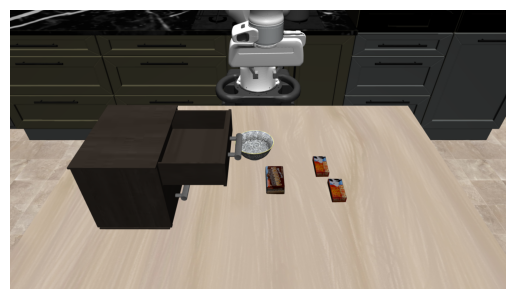

In [9]:
display_image(obs["agentview_image"].transpose(1, 2, 0))

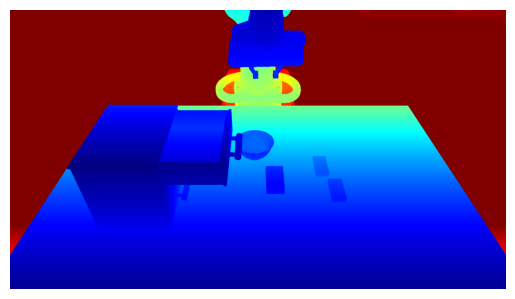

In [10]:
display_image(obs["agentview_depth"], depth=True)

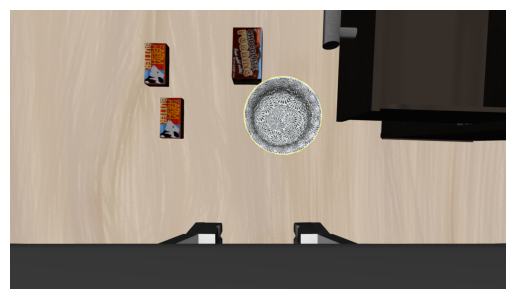

In [11]:
display_image(obs["robot0_eye_in_hand_image"].transpose(1, 2, 0))

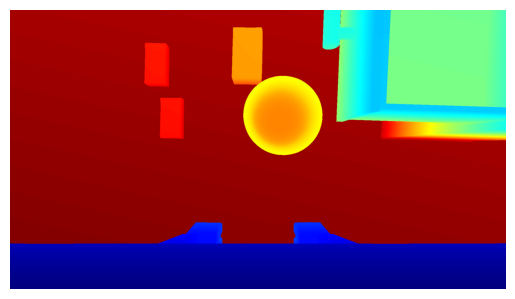

In [12]:
display_image(obs["robot0_eye_in_hand_depth"], depth=True)

In [13]:
obs, _, _, _, _ = env.step(np.array([-0.6588794 ,  0.7854346 , -0.48034656,  0.0050993 ,  0.04032949, 0.01155512, -0.9905531 ]))
obs["robot0_eef_pos"]

[DEBUG] agentview_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True
[DEBUG] robot0_eye_in_hand_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True


array([-0.20592547,  0.0229775 ,  1.1791046 ])

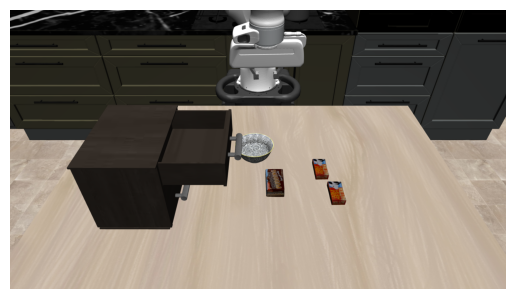

In [14]:
display_image(obs["agentview_image"].transpose(1, 2, 0))

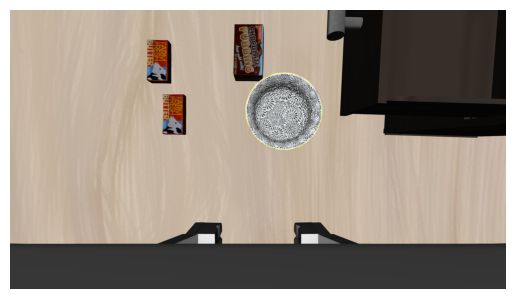

In [15]:
display_image(obs["robot0_eye_in_hand_image"].transpose(1, 2, 0))

In [19]:
obs1, _, _, _, _ = env.step(np.array([-0.6588794 ,  0.7854346 , -0.48034656,  0.0050993 ,  0.04032949, 0.01155512, -0.9905531 ]))


[DEBUG] agentview_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True
[DEBUG] robot0_eye_in_hand_image: shape=(1080, 1920, 3), dtype=uint8, strides=(5760, 3, 1), C_CONTIG=True


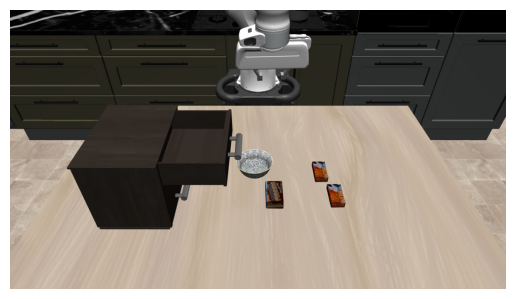

In [20]:
display_image(obs1["agentview_image"].transpose(1, 2, 0))

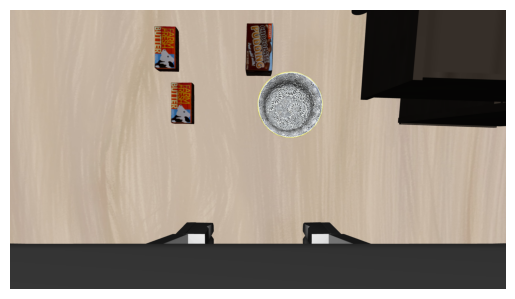

In [21]:
display_image(obs1["robot0_eye_in_hand_image"].transpose(1, 2, 0))